# Interactuando con la API de Spotify

Spotify se puede utilizar como fuente de datos para varios proyectos de ciencia de datos. En este ejercicio, aprenderemos a interactuar con la API de esta red social. `Spotipy` es una librería de código abierto y para Python que permite hacer un uso a alto nivel de la API de Spotify.

## 🟠Paso 1: Crear una cuenta de desarrollador de Spotify

El primer paso es crear una aplicación para poder acceder a los servicios API de Spotify. Toda la información la puedes encontrar [aquí](https://developer.spotify.com/documentation/web-api).

Una vez te hayas logueado usando tu cuenta de Spotify, podrás crear la aplicación para acceder a las credenciales necesarias para consumir la API. Deberás rellenar los siguientes campos:

![Spotify create app](https://github.com/4GeeksAcademy/interacting-with-api-python-project-tutorial/blob/main/assets/spotify_1.PNG?raw=true)

> NOTA: Como no vamos a utilizar esta API desde ninguna otra aplicación web, deja el campo de **Redirect URI** como `http://localhost/`.

Una vez completes el formulario, ya tendrás tu aplicación creada. A continuación, en el apartado de **settings** podrás encontrar tu `Client ID` y `Client Secret`.

## 🟠Paso 2: Configuración inicial

- Crear un archivo `app.py` dentro de la carpeta `./src/`.
- Asegúrate de tener instalada la librería de Python que vamos a utilizar, y si no, instálala: `pip install spotipy`.

## 🟠Paso 3: Variables de entorno

Debes proporcionar la clave y el token de Spotify para poder utilizar la API y acceder a sus funcionalidades. Como vimos en el proyecto anterior, esto puedes hacerlo fácilmente creando un fichero `.env` en el directorio raíz del proyecto.

El tercer paso es crear un archivo `.env` en tu proyecto y agrega tus claves secretas o contraseñas:

```py
CLIENT_ID="insert your client key"
CLIENT_SECRET="insert your client secret"
```

> NOTA: Asegúrate de agregar el `.env` dentro de tu archivo `.gitignore`, el cual no queremos guardar en el control de fuente, para que no estés poniendo en riesgo información potencialmente confidencial.

Ahora, debes instalar `python-dotenvpackage`. Este es un paquete de Python que permite que tu aplicación de Python lea un archivo `.env`. Este paquete buscará un `.env` y, si lo encuentra, expondrá las variables que contiene a la aplicación.

Ejemplo:

```py
from dotenv import load_dotenv
load_dotenv()

import os

client_id = os.environ.get("CLIENT_ID")
client_secret = os.environ.get("CLIENT_SECRET")
```

## 🟠Paso 4: Inicializar la biblioteca Spotipy

- Importar Spotipy.
- Realizar la conexión con la API. Para ello, puedes utilizar la función `spotipy.Spotify()`.

> NOTA: Utiliza la siguiente documentación como guía sobre los parámetros: https://spotipy.readthedocs.io/en/2.22.1


## 🟠Paso 5: Realizar solicitudes a la API

- Comienza a interactuar con la API de Spotify: Obtén de tu artista favorito, el top 10 de sus canciones. Para ello, tendrás que buscar el `ID` del artista para usarlo en la librería. Este identificador es la dirección web que tiene el artista en Spotify:

![Buscar el identificador del artista en Spotify](https://github.com/4GeeksAcademy/interacting-with-api-python-project-tutorial/blob/main/assets/spotify_2.png?raw=true)

- Una vez tengas la respuesta de la API, quédate con el elemento `tracks`, que contendrá las canciones con más reproducciones del artista, quédate con el nombre de la canción, la popularidad y la duración (en minutos).

In [15]:
import os
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from dotenv import load_dotenv

# 🔥Cargar las variables de entorno desde el archivo .env
load_dotenv() #lee el archivo .env y lo carga en el entorno.


# 🔥Obtener credenciales desde variables de entorno
client_id = os.getenv("CLIENT_ID")
client_secret = os.getenv("CLIENT_SECRET")


# 🔥Configurar autenticación con SpotifyClientCredentials:

client_credentials_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)

    # SpotifyClientCredentials es una clase de spotipy que maneja la autenticación sin necesidad 
    # de interacción del usuario (es decir, sin login manual).
    # Se le pasan client_id y client_secret, que obtienes de la API de Spotify y que se almacenan
    # en tu .env.
    # Esta clase genera un token de acceso automáticamente para autenticar tus solicitudes.

    # Básicamente, esta línea configura un gestor de credenciales que se encargará de obtener
    # y renovar el token de acceso para hacer peticiones a la API de Spotify.


# 🔥Creación del cliente de Spotify:

sp = spotipy.Spotify(auth_manager=client_credentials_manager)  # auth_manager=client_credentials_manager se usa en lugar del antiguo método.

  
    # Aquí creamos un objeto sp, que representa el cliente de Spotify.
    # Se le pasa auth_manager=client_credentials_manager, lo que significa que sp usará 
    # ese gestor de credenciales para autenticarse en cada solicitud.
    # Una vez creado sp, puedes usarlo para hacer llamadas a la API, como sp.artist_top_tracks() 
    # o sp.search().
    
    # En resumen, sp es ahora un cliente autenticado con el que puedes interactuar con la API 
    # de Spotify sin preocuparte por la autenticación manual.


# 🔍 ¿Cómo funciona esto internamente?
#     SpotifyClientCredentials obtiene un token de acceso desde Spotify usando client_id y client_secret.
#     Este token de acceso se usa automáticamente en cada petición a la API.
#     Cuando el token expira, spotipy obtiene uno nuevo automáticamente.



# 🔥Obtener las canciones más populares de un artista
artist_id = "33qOK5uJ8AR2xuQQAhHump"
response = sp.artist_top_tracks(artist_id, country="UY")  
    # Llama a la API de Spotify usando el método artist_top_tracks() del objeto sp para obtener 
    # las 10 canciones más populares de un artista específico.
    # 1. artist_id:
    # Es el ID único del artista en Spotify.
    # En tu caso: "33qOK5uJ8AR2xuQQAhHump" (corresponde a Teddy Swims).
    # Se usa este ID porque es más confiable que el nombre del artista (evita confusiones con artistas con nombres similares).

    # 2. country="US"
    # Este parámetro es obligatorio.
    # Filtra las canciones más populares según el país.
    # "US" significa que te traerá las canciones más populares en Estados Unidos.
    # Puedes cambiarlo por otro código de país si lo necesitas (ej: "MX", "ES", "AR").

    #3. ¿Qué devuelve response?
    # Es un diccionario con información sobre las 10 canciones más populares del artista.
    # La estructura de response es así:
        #     {
        #   "tracks": [
        #     {
        #       "name": "Lose Control",
        #       "popularity": 85,
        #       "duration_ms": 194000,
        #       "album": {
        #         "name": "Lose Control - Single"
        #       }
        #     },
        #     {
        #       "name": "Bed on Fire",
        #       "popularity": 78,
        #       "duration_ms": 210000,
        #       "album": {
        #         "name": "Teddy Swims Unplugged"
        #       }
        #     }
        #     // ... Otras 8 canciones
        #   ]
        # }

# 🔥Procesar la respuesta
if response:
    tracks = response["tracks"]
    tracks = [{k: (v / (1000 * 60)) % 60 
               if k == "duration_ms" else v for k, v in track.items() 
               if k in ["name", "popularity", "duration_ms"]} for track in tracks]
    # Conversión de duration_ms a minutos y segundos. 
    # Se transforma duration_ms de milisegundos a minutos

    
    for track in tracks:
        print(track) # Imprimir resultados. Se muestran los datos de las canciones en la consola.


{'duration_ms': 3.5114666666666667, 'name': 'Lose Control', 'popularity': 88}
{'duration_ms': 3.0762833333333335, 'name': 'Bad Dreams', 'popularity': 78}
{'duration_ms': 3.5441333333333334, 'name': 'The Door', 'popularity': 85}
{'duration_ms': 2.4617, 'name': 'Are You Even Real (feat. Givēon)', 'popularity': 73}
{'duration_ms': 3.463233333333333, 'name': 'Somethin’ ‘Bout A Woman (feat. Teddy Swims)', 'popularity': 78}
{'duration_ms': 2.9180166666666665, 'name': 'Devil in a Dress', 'popularity': 76}
{'duration_ms': 3.5079333333333333, 'name': 'The Door - CYRIL Remix', 'popularity': 76}
{'duration_ms': 2.9404, 'name': 'Guilty', 'popularity': 76}
{'duration_ms': 3.2052833333333335, 'name': 'Hammer to the Heart', 'popularity': 73}
{'duration_ms': 4.070583333333333, 'name': 'All That Really Matters', 'popularity': 72}


## Paso 6: Transformar a Pandas DataFrame

Puesto que el resultado obtenido en estos pasos es susceptible de tener formato de tabla, conviértelo en un DataFrame importando los datos en su formato de diccionario. A continuación, ordena las canciones por popularidad creciente y muestra el top 3 resultante.

In [16]:
#🔥Transform to Pandas DataFrame: 
  
import pandas as pd

tracks_df = pd.DataFrame(tracks)
tracks_df.sort_values(["popularity"], ascending=False, inplace = True)
    # sort_values(["popularity"]) → Ordena el DataFrame en base a la columna "popularity". 
    # Se ordena de forma decreciente, ya que a mi entender quiero obtener las 3 canciones con mayor popularidad.
    # inplace=True → Modifica el DataFrame directamente en vez de crear una copia.

print(tracks_df.head(3))

   duration_ms          name  popularity
0     3.511467  Lose Control          88
2     3.544133      The Door          85
1     3.076283    Bad Dreams          78


## Paso 7: Analizar relación estadística

¿Tiene relación la duración con la popularidad? ¿Podríamos decir que una canción que dure poco tiempo puede ser más popular que otra que dure más? Analízalo graficando un `scatter plot` y argumenta tu respuesta.

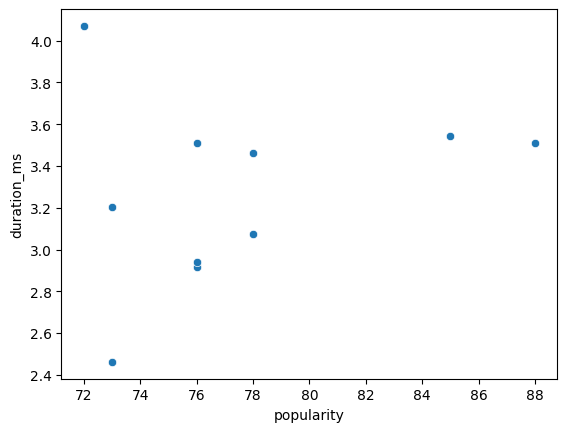

In [17]:
#🔥Analizar relación estadística:
# ¿Tiene relación la duración con la popularidad? 
# ¿Podríamos decir que una canción que dure poco tiempo puede ser más popular 
# que otra que dure más? 
# Analízalo graficando un `scatter plot` y argumenta tu respuesta.

import seaborn as sns

# A scatter plot is a good alternative to determine visually and graphically whether 
# two variables may or may not be related to each other:

scatter_plot = sns.scatterplot(data = tracks_df, x = "popularity", y = "duration_ms")

    # Crea un gráfico de dispersión (scatter plot).
    # Usa tracks_df, el DataFrame que contiene las canciones con las columnas:
    #     popularity (popularidad de la canción). 
    #     duration_ms (duración en milisegundos).
    # Ejes del gráfico:
    #     Eje X (x="popularity") → Popularidad de la canción.
    #     Eje Y (y="duration_ms") → Duración de la canción en milisegundos.

    # ¿Qué representa?
    # Cada punto en el gráfico representa una canción con su duración y popularidad.
    # Si los puntos siguen un patrón claro (por ejemplo, una línea), podríamos decir 
    # que hay una relación estadística entre ambas variables.

fig = scatter_plot.get_figure() # obtiene la figura del gráfico.
fig.savefig("scatter_plot.png") # guarda el gráfico como imagen en el archivo "scatter_plot.png".

As can be seen, there is no direct relationship between the length of the song and its popularity.